In [39]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
import pandas as pd

from keras.models import Sequential
from keras.layers import Dense, Activation, Convolution2D, Flatten, Dropout, MaxPooling2D
from keras.optimizers import SGD
import tensorflow as tf

from imblearn.over_sampling import SMOTE

In [40]:
df = pd.read_csv('creditcard.csv', low_memory=False)
X = df.iloc[:,:-1]
y = df['Class']

In [41]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [42]:
frauds = df.loc[df['Class'] == 1]
non_frauds = df.loc[df['Class'] == 0]
print("We have", len(frauds), "fraud data points and", len(non_frauds), "regular data points.")

We have 492 fraud data points and 284315 regular data points.


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [44]:
print("Size of training set: ", X_train.shape)

Size of training set:  (190820, 30)


# Simplest Neural Network (for testing)

In [45]:
model = Sequential()
model.add(Dense(30, input_dim=30, activation='relu'))     # kernel_initializer='normal'
model.add(Dense(1, activation='sigmoid'))                 # kernel_initializer='normal'
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.fit(X_train.to_numpy(), y_train, epochs=1)

5964/5964 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - accuracy: 0.9965 - loss: 4.5353


In [48]:
print("Loss: ", model.evaluate(X_test.to_numpy(), y_test, verbose=0))

Loss:  [7.6776323318481445, 0.9980210065841675]


In [49]:
y_predicted = model.predict(X_test.to_numpy()).T[0].astype(int)

2938/2938 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step


Confusion Matrix:
 [[93805     0]
 [  181     1]]


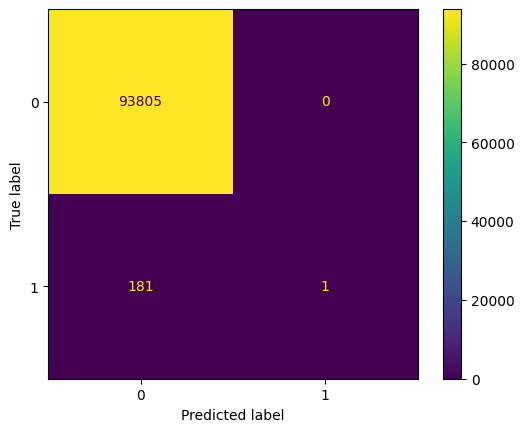

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_right = np.array(y_test)
confusion_matrix_result = confusion_matrix(y_right, y_predicted)

print("Confusion Matrix:\n", confusion_matrix_result)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_result)
disp.plot()
plt.show()

# Oversampling with gaussian noise (commented out)

In [51]:
# noise = np.random.normal(0,.1,30)

# # 0 is the mean of the normal distribution you are choosing from
# # 1 is the standard deviation of the normal distribution
# # 100 is the number of elements you get in array noise
# noise

In [52]:
# frauds.head()

In [53]:
# for i in range(300):
#     #frauds.iloc[i] += noise[i]
#     frauds.append(frauds.iloc[i % 30] + noise[i % 30])

In [54]:
# NEED TO ADD A (DIFFERENT BUT SIMILAR) RANDOM NOISE ARRAY TO EVERY ROW OF FRAUDS TABLE (WITHOUT CLASS)
# THEN ADD THIS TO ORIGINAL FRAUDS TABLE (MAKING MORE DATA POINTS)
# AND RE SPLIT DATA AND DO NEURAL NET
# ALSO TRY FORCING 50% OF FRAUDS INTO TRAINING SET AND 50% INTO TEST SET

# Neural Network after Oversampling, Scaling, and PCA (10 components)

In [59]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# Convert training data to a normal pandas DataFrame
df2 = pd.DataFrame(X_train.copy())
df2["Class"] = y_train.values if hasattr(y_train, "values") else y_train

# Apply SMOTE
X_data = df2.drop("Class", axis=1)
y_data = df2["Class"]

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_data, y_data)

# Scale the data
scaler = StandardScaler()
data = scaler.fit_transform(X_resampled)

# Apply PCA
pca = PCA(n_components=10)
X2 = pca.fit_transform(data)

# IMPORTANT: create y2
y2 = y_resampled.to_numpy()

print("Original shape:", X_data.shape)
print("After SMOTE:", X_resampled.shape)
print("After PCA:", X2.shape)
print("y2 shape:", y2.shape)

Original shape: (190820, 30)
After SMOTE: (381020, 30)
After PCA: (381020, 10)
y2 shape: (381020,)


In [57]:
model2 = Sequential()
model2.add(Dense(10, input_dim=10, activation='relu')) 
model2.add(Dense(27, activation='relu'))
model2.add(Dense(20, activation='relu'))
model2.add(Dense(15, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.summary()

c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 27)             │           297 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 20)             │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,298 (5.07 KB)

 Trainable params: 1,298 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
X2_test = pca.fit_transform(X_test)
h = model2.fit(X2, y2, epochs=5, validation_data=(X2_test, y_test))

Epoch 1/5
11907/11907 ━━━━━━━━━━━━━━━━━━━━ 45863s 4s/step - accuracy: 0.9703 - loss: 0.0798 - val_accuracy: 0.4685 - val_loss: 13701.7227
Epoch 2/5
11907/11907 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.9827 - loss: 0.0478 - val_accuracy: 0.4684 - val_loss: 13049.2939
Epoch 3/5
11907/11907 ━━━━━━━━━━━━━━━━━━━━ 62s 5ms/step - accuracy: 0.9864 - loss: 0.0380 - val_accuracy: 0.4685 - val_loss: 2030.4935
Epoch 4/5
11907/11907 ━━━━━━━━━━━━━━━━━━━━ 70s 6ms/step - accuracy: 0.9882 - loss: 0.0331 - val_accuracy: 0.4684 - val_loss: 12342.4551
Epoch 5/5
11907/11907 ━━━━━━━━━━━━━━━━━━━━ 75s 6ms/step - accuracy: 0.9897 - loss: 0.0294 - val_accuracy: 0.4685 - val_loss: 17289.2480


In [61]:
print("Loss: ", model2.evaluate(X2_test, y_test, verbose=2))

2938/2938 - 12s - 4ms/step - accuracy: 0.4685 - loss: 17289.2480
Loss:  [17289.248046875, 0.4684690535068512]


In [62]:
y2_predicted = np.round(model2.predict(X2_test)).T[0]
y2_correct = np.array(y_test)

2938/2938 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step


Confusion Matrix:
[[43911 49894]
 [   63   119]]


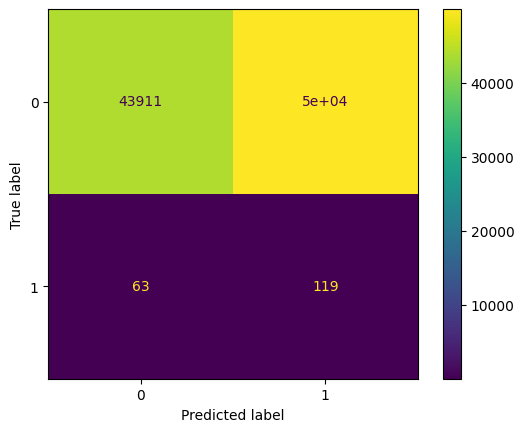

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y2_correct, y2_predicted)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [65]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y2_correct, y2_predicted))
print("Precision:", precision_score(y2_correct, y2_predicted))
print("Recall:", recall_score(y2_correct, y2_predicted))
print("F1 Score:", f1_score(y2_correct, y2_predicted))

print("\nClassification Report:")
print(classification_report(y2_correct, y2_predicted))

Accuracy: 0.46846904359113495
Precision: 0.00237938136084618
Recall: 0.6538461538461539
F1 Score: 0.00474150811833848

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.47      0.64     93805
           1       0.00      0.65      0.00       182

    accuracy                           0.47     93987
   macro avg       0.50      0.56      0.32     93987
weighted avg       1.00      0.47      0.64     93987



In [66]:
# Transform TEST data using the SAME scaler and PCA
X_test_scaled = scaler.transform(X_test)
X2_test = pca.transform(X_test_scaled)

# Evaluate the neural network
loss, accuracy = model2.evaluate(X2_test, y_test, verbose=0)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Predictions
y2_predicted = np.round(model2.predict(X2_test)).astype(int).flatten()
y2_correct = np.array(y_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y2_correct, y2_predicted)

print("\nConfusion Matrix:")
print(cm)

c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Test Loss: 75772.625
Test Accuracy: 0.0019364380277693272
2938/2938 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

Confusion Matrix:
[[    0 93805]
 [    0   182]]


In [67]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Convert data to NumPy arrays
X_train_nn = np.asarray(X2)
y_train_nn = np.asarray(y_resampled).astype(int)

# Transform test data using the SAME scaler and PCA
X_test_scaled = scaler.transform(X_test)
X_test_nn = pca.transform(X_test_scaled)

y_test_nn = np.asarray(y_test).astype(int)

print("Training data:", X_train_nn.shape)
print("Training labels:", y_train_nn.shape)
print("Test data:", X_test_nn.shape)
print("Test labels:", y_test_nn.shape)

# Build a fresh neural network
model3 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model3.fit(
    X_train_nn,
    y_train_nn,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, accuracy = model3.evaluate(
    X_test_nn,
    y_test_nn,
    verbose=0
)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

# Predictions
y_pred = (model3.predict(X_test_nn) >= 0.5).astype(int).flatten()

# Confusion matrix
cm = confusion_matrix(y_test_nn, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_nn, y_pred))

c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training data: (381020, 10)
Training labels: (381020,)
Test data: (93987, 10)
Test labels: (93987,)
Epoch 1/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9405 - loss: 0.1593 - val_accuracy: 0.9265 - val_loss: 0.1724
Epoch 2/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9691 - loss: 0.0935 - val_accuracy: 0.9473 - val_loss: 0.1214
Epoch 3/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9724 - loss: 0.0834 - val_accuracy: 0.9492 - val_loss: 0.1184
Epoch 4/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9741 - loss: 0.0766 - val_accuracy: 0.9572 - val_loss: 0.1009
Epoch 5/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9764 - loss: 0.0699 - val_accuracy: 0.9583 - val_loss: 0.0918
Epoch 6/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9773 - loss: 0.0647 - val_accuracy: 0.9658 - val_loss: 0.0787
Epoch 7/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9786 - loss: 0.0602 - val_accuracy: 0.9695 - val_los

c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [68]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model3.predict(X_test_nn, verbose=0) >= 0.5).astype(int).flatten()

cm = confusion_matrix(y_test_nn, y_pred)

print("CONFUSION MATRIX")
print(cm)

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test_nn, y_pred, digits=4))

CONFUSION MATRIX
[[    0 93805]
 [    0   182]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000     93805
           1     0.0019    1.0000    0.0039       182

    accuracy                         0.0019     93987
   macro avg     0.0010    0.5000    0.0019     93987
weighted avg     0.0000    0.0019    0.0000     93987



c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [69]:
# ============================================
# CLEAN NEURAL NETWORK PIPELINE
# ============================================

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

# Convert to NumPy
Xtr = np.asarray(X_train)
Xte = np.asarray(X_test)
ytr = np.asarray(y_train).astype(int)
yte = np.asarray(y_test).astype(int)

print("Original training:", Xtr.shape)
print("Original test:", Xte.shape)

# --------------------------------------------
# STEP 1: SCALE
# Fit scaler ONLY on original training data
# --------------------------------------------

scaler_clean = StandardScaler()

Xtr_scaled = scaler_clean.fit_transform(Xtr)
Xte_scaled = scaler_clean.transform(Xte)

# --------------------------------------------
# STEP 2: SMOTE
# Apply SMOTE ONLY to training data
# --------------------------------------------

smote_clean = SMOTE(random_state=42)

Xtr_balanced, ytr_balanced = smote_clean.fit_resample(
    Xtr_scaled,
    ytr
)

print("After SMOTE:", Xtr_balanced.shape)

# --------------------------------------------
# STEP 3: PCA
# Fit PCA ONLY on training data
# --------------------------------------------

pca_clean = PCA(n_components=10, random_state=42)

Xtr_pca = pca_clean.fit_transform(Xtr_balanced)
Xte_pca = pca_clean.transform(Xte_scaled)

print("Training after PCA:", Xtr_pca.shape)
print("Test after PCA:", Xte_pca.shape)

# --------------------------------------------
# STEP 4: NEW NEURAL NETWORK
# --------------------------------------------

model_clean = Sequential([
    Dense(32, activation='relu', input_shape=(10,)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_clean.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# --------------------------------------------
# STEP 5: TRAIN
# --------------------------------------------

history_clean = model_clean.fit(
    Xtr_pca,
    ytr_balanced,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# --------------------------------------------
# STEP 6: TEST
# --------------------------------------------

test_loss, test_accuracy = model_clean.evaluate(
    Xte_pca,
    yte,
    verbose=0
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# --------------------------------------------
# STEP 7: PREDICTIONS
# --------------------------------------------

y_pred_clean = (
    model_clean.predict(Xte_pca, verbose=0) >= 0.5
).astype(int).flatten()

# --------------------------------------------
# STEP 8: CONFUSION MATRIX
# --------------------------------------------

cm_clean = confusion_matrix(yte, y_pred_clean)

print("\nConfusion Matrix:")
print(cm_clean)

# --------------------------------------------
# STEP 9: CLASSIFICATION REPORT
# --------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        yte,
        y_pred_clean,
        digits=4
    )
)

Original training: (190820, 30)
Original test: (93987, 30)
After SMOTE: (381020, 30)
Training after PCA: (381020, 10)
Test after PCA: (93987, 10)
Epoch 1/10


c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1191/1191 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9333 - loss: 0.2025 - val_accuracy: 0.8939 - val_loss: 0.1900
Epoch 2/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9506 - loss: 0.1276 - val_accuracy: 0.9165 - val_loss: 0.1514
Epoch 3/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9545 - loss: 0.1172 - val_accuracy: 0.9430 - val_loss: 0.1259
Epoch 4/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9589 - loss: 0.1093 - val_accuracy: 0.9434 - val_loss: 0.1268
Epoch 5/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9623 - loss: 0.1024 - val_accuracy: 0.9495 - val_loss: 0.1162
Epoch 6/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9647 - loss: 0.0974 - val_accuracy: 0.9519 - val_loss: 0.1148
Epoch 7/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9666 - loss: 0.0930 - val_accuracy: 0.9549 - val_loss: 0.1014
Epoch 8/10
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9679 - loss: 0.0886 - val_accurac

In [72]:
from sklearn.metrics import confusion_matrix, classification_report

# Generate fresh predictions from the trained model
y2_predicted = (model2.predict(X2_test) >= 0.5).astype(int).ravel()

# Actual test labels
y2_correct = np.array(y_test)

# Results
cm = confusion_matrix(y2_correct, y2_predicted)

print("CONFUSION MATRIX")
print(cm)

print("\nCLASSIFICATION REPORT")
print(classification_report(y2_correct, y2_predicted, digits=4))

2938/2938 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
CONFUSION MATRIX
[[    0 93805]
 [    0   182]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000     93805
           1     0.0019    1.0000    0.0039       182

    accuracy                         0.0019     93987
   macro avg     0.0010    0.5000    0.0019     93987
weighted avg     0.0000    0.0019    0.0000     93987



c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag